In [1]:
#импорт библиотек
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации

from sklearn import linear_model #линейные моделиё
from sklearn import tree #деревья решений
from sklearn import ensemble #ансамбли
from sklearn import metrics #метрики
from sklearn import preprocessing #предобработка
from sklearn.model_selection import train_test_split #сплитование выборки
from sklearn.model_selection import cross_validate

%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

In [2]:
def get_estimator_log_reg(**params:dict | None) -> linear_model.LogisticRegression:
    """ Функция генерации логистической регрессии (LogisticRegression).
        Принимает на вход словарь с параметрами. Если словарь пустой - создаётся модель с параметрами по умолчанию.

    Args:
        params (dict | None):   внешний словарь параметров модели | значение None (пустой словарь). 
                                При значении None генерируется стандартный объект класса + заданные параметры в estimator_log_reg

    Returns:
        estimator_log_reg(linear_model.LogisticRegression): объект класса логистическая регрессия (LogisticRegression)
    """
    estimator_log_reg = linear_model.LogisticRegression(
        **params,
        random_state=42,
        n_jobs=-1
    )
    return estimator_log_reg

In [3]:
# создаём объект класса RandomForestClassifier как estimator
def get_estimator_rf_clf(**params:dict | None) -> ensemble.RandomForestClassifier:
    """ Функция генерации "случайного леса" (RandomForestClassifier).
        Принимает на вход словарь с параметрами. Если словарь пустой - создаётся модель с параметрами по умолчанию.

    Args:
        params (dict | None):   внешний словарь параметров модели | значение None (пустой словарь). 
                                При значении None генерируется стандартный объект класса + заданные параметры в estimator_rf_clf
        
    Returns:
        estimator_rf_clf(ensemble.RandomForestClassifier): объект класса "случайный лес" (RandomForestClassifier)
    """
    estimator_rf_clf = ensemble.RandomForestClassifier(
        **params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    return estimator_rf_clf

### Описание задачи

Необходимо предсказать биологический ответ молекул (столбец 'Activity') по их химическому составу.

Необходимо обучить две модели: логистическую регрессию и случайный лес. 

Далее нужно сделать подбор гиперпараметров с помощью базовых и продвинутых методов оптимизации. Важно использовать все четыре метода (GridSeachCV, RandomizedSearchCV, Hyperopt, Optuna) хотя бы по разу, максимальное количество итераций не должно превышать 50.

В качестве метрики будем использовать F1-score

### Знакомство с данными и их исследование

In [4]:
data = pd.read_csv('data/_train_sem09.csv')
data.head()

,Activity,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,D1767,D1768,D1769,D1770,D1771,D1772,D1773,D1774,D1775,D1776
0,1,0.000000,0.497009,0.10,0.0,0.132956,0.678031,0.273166,0.585445,0.743663,...,0,0,0,0,0,0,0,0,0,0
1,1,0.366667,0.606291,0.05,0.0,0.111209,0.803455,0.106105,0.411754,0.836582,...,1,1,1,1,0,1,0,0,1,0
2,1,0.033300,0.480124,0.00,0.0,0.209791,0.610350,0.356453,0.517720,0.679051,...,0,0,0,0,0,0,0,0,0,0
3,1,0.000000,0.538825,0.00,0.5,0.196344,0.724230,0.235606,0.288764,0.805110,...,0,0,0,0,0,0,0,0,0,0
4,0,0.100000,0.517794,0.00,0.0,0.494734,0.781422,0.154361,0.303809,0.812646,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# проверка на пропуски
data[data.isnull().any(axis=1)]

,Activity,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,D1767,D1768,D1769,D1770,D1771,D1772,D1773,D1774,D1775,D1776


Activity
1    0.542255
0    0.457745
Name: proportion, dtype: float64


<Axes: xlabel='Activity', ylabel='count'>

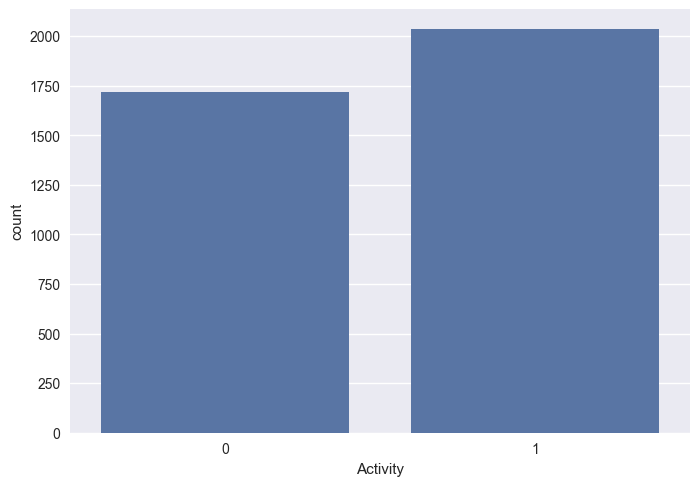

In [6]:
# сбалансированность классов
print(data['Activity'].value_counts(normalize=True))
sns.countplot(data=data, x='Activity')

Набор данных сбалансирован. 

Разделяем выборку на тренировочную и тестовую в соотношении 80/20. Для сохранения соотношений целевого признака используем параметр stratify (стратифицированное разбиение). 

На каждом этапе будем проводить кросс-валидацию, поэтому выделение валидационной выборки не нужно.

In [7]:
# матрица наблюдений
X = data.drop(['Activity'], axis=1)

# вектор ответов
y = data['Activity']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.2)

In [9]:
def get_model_metrics(
    estimator_:linear_model.LogisticRegression | ensemble.RandomForestClassifier, 
    opt_method:str=None, 
    cv_:int | None=5, 
    X_train_:pd.DataFrame=X_train, y_train_:pd.Series=y_train, 
    X_test_:pd.DataFrame=X_test, y_test_:pd.Series=y_test,
    ) -> None:
    """ Функция вывода метрик.

    Parameters
    ----------
        estimator_ (linear_model.LogisticRegression | ensemble.RandomForestClassifier) : модель для расчёта метрик на кросс-валидации
            
        opt_method (str) : метод оптимизации. Defaults to None.

        cv_ (int, optional) : кросс-валидатор модели. Defaults to 5.
        
        X_train_ (pd.DataFrame, optional) : тренировочный датасет. Defaults to X_train.
        
        y_train_ (pd.Series, optional) : тренировочный вектор целевых значений. Defaults to y_train.
        
        X_test_ (pd.DataFrame, optional) : тестовый датасет. Defaults to X_test.
        
        y_test_ (pd.Series, optional) : тестовый вектор целевых значений. Defaults to y_test.
    """

    cv_metrics = cross_validate(
            estimator=estimator_,           # модель
            X=X_train_,                     # матрица наблюдений X
            y=y_train_,                     # вектор ответов y
            cv=5,                         # число фолдов кросс-валидатора StratifiedKFold
            scoring=['f1', 'accuracy',
                'recall', 'precision'],     # метрики
            return_train_score=True,        # подсчёт метрики на тренировочных фолдах
            n_jobs=-1
        )

    # обучение модели и предсказание значений для тестовой выборки
    estimator_.fit(X_train_, y_train_)
    y_pred_test_estimator_ = estimator_.predict(X_test_)
    
    # заголовок отчёта
    if opt_method:
        print(f'-= {estimator_.__class__.__name__}, {opt_method} =-')
    else:
        print(f'-= {estimator_.__class__.__name__}, Baseline =-')
    
    # выводим метрику на тестовой выборке
    print(f'f1_score на тестовом наборе: {metrics.f1_score(y_test_, y_pred_test_estimator_):.3f}\n')
        
    # выводим метрики на кросс-валидации
    print(f"f1_score на тренировочном наборе: {np.mean(cv_metrics['train_f1']):.3f}")
    print(f"accuracy на валидационном наборе: {np.mean(cv_metrics['test_accuracy']):.3f}")
    print(f"f1_score на валидационном наборе: {np.mean(cv_metrics['test_f1']):.3f}")

### Логистическая регрессия

#### Baseline

In [44]:
# Оцениваем метрику f1-score при установленных по умолчанию гиперпараметров:
get_model_metrics(get_estimator_log_reg())

-= LogisticRegression, Baseline =-
f1_score на тестовом наборе: 0.775

f1_score на тренировочном наборе: 0.905
accuracy на валидационном наборе: 0.749
f1_score на валидационном наборе: 0.773


#### GridSearchCV

In [45]:
# создаем сетку параметров
log_reg_C_values = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 1]
l1_ratio = np.linspace(0, 1, num=10)
param_grid_log_reg = [
    {'penalty': ['l2', 'none'],     # тип регуляризации
    'solver': ['lbfgs', 'sag'],     # алгоритм оптимизации
    'C': log_reg_C_values           # уровень силы регуляризации
    },
            
    {'penalty': ['l1', 'l2'] ,
    'solver': ['liblinear'],
    'C': log_reg_C_values
    },
            
    {'penalty': ['l1', 'l2', 'elasticnet', 'none'] ,
    'solver': ['saga'],
    'C': log_reg_C_values,
    # 'l1_ratio': stats.uniform(0, 1)
    'l1_ratio': l1_ratio
    }
]

In [46]:
from sklearn.model_selection import GridSearchCV

# создаем объект класса GridSearchCV
gscv_log_reg = GridSearchCV(
    estimator=get_estimator_log_reg(), 
    param_grid=param_grid_log_reg, 
    cv=5, 
    n_jobs=-1,
)

# обучаем модель на кросс-валидации
%time gscv_log_reg.fit(X_train, y_train)

print(f'Наилучшие значения гиперпараметров: {gscv_log_reg.best_params_}')

c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning:


480 fits failed out of a total of 1840.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
125 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1356, in wrapper
    estimator._validate_params()
  File "c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-package

CPU times: total: 14.1 s
Wall time: 20min 38s
Наилучшие значения гиперпараметров: {'C': 0.05, 'l1_ratio': np.float64(0.1111111111111111), 'penalty': 'elasticnet', 'solver': 'saga'}


c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



In [47]:
# рассчитываем и выводим метрики
get_model_metrics(
    get_estimator_log_reg(**gscv_log_reg.best_params_),
    gscv_log_reg.__class__.__name__
)
print(f'Наилучшие значения гиперпараметров: {gscv_log_reg.best_params_}')

-= LogisticRegression, GridSearchCV =-
f1_score на тестовом наборе: 0.781

f1_score на тренировочном наборе: 0.831
accuracy на валидационном наборе: 0.770
f1_score на валидационном наборе: 0.795
Наилучшие значения гиперпараметров: {'C': 0.05, 'l1_ratio': np.float64(0.1111111111111111), 'penalty': 'elasticnet', 'solver': 'saga'}


c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



#### RandomizedSearchCV

In [48]:
from sklearn.model_selection import RandomizedSearchCV

# создаем объект класса RandomizedSearch
rscv_log_reg = RandomizedSearchCV(
    estimator=get_estimator_log_reg(), 
    param_distributions=param_grid_log_reg,
    cv=5, 
    n_jobs=-1,
    n_iter=25
)

# обучаем модель на кросс-валидации
%time rscv_log_reg.fit(X_train, y_train) 

print(f'Наилучшие значения гиперпараметров: {rscv_log_reg.best_params_}')

c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning:


25 fits failed out of a total of 125.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1356, in wrapper
    estimator._validate_params()
  File "c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sk

CPU times: total: 4.91 s
Wall time: 1min 28s
Наилучшие значения гиперпараметров: {'solver': 'saga', 'penalty': 'l1', 'l1_ratio': np.float64(0.0), 'C': 0.3}


c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



In [49]:
# рассчитываем и выводим метрики
get_model_metrics(
    get_estimator_log_reg(**rscv_log_reg.best_params_),
    rscv_log_reg.__class__.__name__
)
print(f'Наилучшие значения гиперпараметров: {rscv_log_reg.best_params_}')

c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1213: UserWarning:

l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)



-= LogisticRegression, RandomizedSearchCV =-
f1_score на тестовом наборе: 0.782

f1_score на тренировочном наборе: 0.838
accuracy на валидационном наборе: 0.767
f1_score на валидационном наборе: 0.791
Наилучшие значения гиперпараметров: {'solver': 'saga', 'penalty': 'l1', 'l1_ratio': np.float64(0.0), 'C': 0.3}


c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



#### Hyperopt

In [50]:
from sklearn.model_selection import cross_val_score
import hyperopt
from hyperopt import hp, fmin, tpe, Trials
from functools import partial

# зададим пространство поиска гиперпараметров
# т.к. для каждого типа регуляции подходят только определённые комбинации оптимизации
hyperopt_space_log_reg_1 = {
    'penalty': hp.choice('penalty', ['l2']),    # тип регуляризации
    'solver': hp.choice('solver', ['lbfgs', 'sag']),    # алгоритм оптимизации
    'C': hp.choice('C', log_reg_C_values)               # уровень силы регуляризации
}

#--------------------------------------------------------------------------------
hyperopt_space_log_reg_2 = {
    'penalty': hp.choice('penalty', ['l1', 'l2']), 
    'solver': hp.choice('solver', ['liblinear']), 
    'C': hp.choice('C', log_reg_C_values)
}

#--------------------------------------------------------------------------------
hyperopt_space_log_reg_3 = {
    'penalty': hp.choice('penalty', ['l1', 'l2', 'elasticnet']), 
    'solver': hp.choice('solver', ['saga']),
    'C': hp.choice('C', log_reg_C_values),
    # 0 <= l1_ratio <= 1, обязателен, если penalty='elasticnet'
    'l1_ratio': hp.uniform('l1_ratio', 0, 1)
}

In [51]:
def hyperopt_log_reg(
        space_params:dict, 
        X_train_:pd.DataFrame=X_train, y_train_:pd.Series=y_train, 
        cv_:int=5, 
    ) -> float | np.ndarray:
    """ Функция поиска оптимальных гиперпараметров с помощью Hyperopt

    Args:
        space_params (dict): словарь-"пространство" гиперпараметров
        X_train_ (pd.DataFrame, optional): тренировочный датасет. Defaults to X_train.
        y_train_ (pd.Series, optional): тренировочный вектор целевых значений. Defaults to y_train.
        cv_ (int, optional): числов фолдов на кросс-валидации. Defaults to 5.

    Returns:
        score (float | np.ndarray): метрика | массив метрик
    """

    # повторяющиеся параметры пространства
    params = {
        'penalty': space_params['penalty'], 
        'solver': space_params['solver'], 
        'C': space_params['C'],
    }

    # создаём модель обучения с заданными параметрами
    try:
        model_hyperopt_log_reg_ = get_estimator_log_reg(
            **params,
            l1_ratio=space_params['l1_ratio'],
        )
        
    except KeyError:
        model_hyperopt_log_reg_ = get_estimator_log_reg(
            **params,
        )

    # обучаем модель на кросс-валидации
    score = cross_val_score(
        model_hyperopt_log_reg_, 
        X_train_, y_train_, 
        cv=cv_, 
        scoring='f1', 
        n_jobs=-1
        ).mean()
    
    # метрику необходимо минимизировать, поэтому ставим знак минус,
    # возвращая инвертированное значение
    return -score

In [52]:
%%time
## расчёты для hyperopt_space_log_reg_1
trials_hyperopt_log_reg_1 = Trials()            # используется для логирования результатов

study_hyperopt_log_reg_1 = fmin(
    fn=partial(
        hyperopt_log_reg, 
        X_train_=X_train, y_train_=y_train,
        cv_=5,
    ),                                          # наша функция
    space=hyperopt_space_log_reg_1,             # пространство гиперпараметров
    algo=tpe.suggest,                           # алгоритм оптимизации, установлен по умолчанию, задавать необязательно
    max_evals=25,                               # максимальное количество итераций
    trials=trials_hyperopt_log_reg_1,           # логирование результатов
    rstate=np.random.default_rng(42)            # фиксируем для повторяемости результата
)

print(f'Наилучшие значения гиперпараметров \n' \
    f'{hyperopt.space_eval(hyperopt_space_log_reg_1, study_hyperopt_log_reg_1)}')

100%|██████████| 25/25 [01:35<00:00,  3.80s/trial, best loss: -0.7907284724091234]
Наилучшие значения гиперпараметров 
{'C': 0.05, 'penalty': 'l2', 'solver': 'sag'}
CPU times: total: 1.81 s
Wall time: 1min 35s


In [53]:
%%time
## расчёты для hyperopt_space_log_reg_2
trials_hyperopt_log_reg_2 = Trials()            # используется для логирования результатов

study_hyperopt_log_reg_2 = fmin(
    fn=partial(
        hyperopt_log_reg, 
        X_train_=X_train, y_train_=y_train,
        cv_=5,
    ),                                          # наша функция
    space=hyperopt_space_log_reg_2,             # пространство гиперпараметров
    algo=tpe.suggest,                           # алгоритм оптимизации, установлен по умолчанию, задавать необязательно
    max_evals=25,                        # максимальное количество итераций
    trials=trials_hyperopt_log_reg_2,           # логирование результатов
    rstate=np.random.default_rng(42)   # фиксируем для повторяемости результата
)

print(f'Наилучшие значения гиперпараметров \n' \
    f'{hyperopt.space_eval(hyperopt_space_log_reg_2, study_hyperopt_log_reg_2)}')

100%|██████████| 25/25 [00:19<00:00,  1.31trial/s, best loss: -0.7896620382423479]
Наилучшие значения гиперпараметров 
{'C': 0.05, 'penalty': 'l2', 'solver': 'liblinear'}
CPU times: total: 1.56 s
Wall time: 19.1 s


In [54]:
%%time
## расчёты для hyperopt_space_log_reg_3
trials_hyperopt_log_reg_3 = Trials()            # используется для логирования результатов

study_hyperopt_log_reg_3 = fmin(
    fn=partial(
        hyperopt_log_reg, 
        X_train_=X_train, y_train_=y_train,
        cv_=5,
    ),                                          # наша функция
    space=hyperopt_space_log_reg_3,             # пространство гиперпараметров
    algo=tpe.suggest,                           # алгоритм оптимизации, установлен по умолчанию, задавать необязательно
    max_evals=25,                        # максимальное количество итераций
    trials=trials_hyperopt_log_reg_3,           # логирование результатов
    rstate=np.random.default_rng(42)   # фиксируем для повторяемости результата
)

print(f'Наилучшие значения гиперпараметров \n' \
    f'{hyperopt.space_eval(hyperopt_space_log_reg_3, study_hyperopt_log_reg_3)}')

100%|██████████| 25/25 [03:03<00:00,  7.33s/trial, best loss: -0.7913324555968615]
Наилучшие значения гиперпараметров 
{'C': 0.3, 'l1_ratio': 0.7130445215144277, 'penalty': 'l1', 'solver': 'saga'}
CPU times: total: 2.2 s
Wall time: 3min 3s


Построение метрик моделей по результатам оптимизации Hyperopt

In [55]:
# рассчитываем и выводим метрики
# type: ignore
get_model_metrics(
    get_estimator_log_reg(**hyperopt.space_eval(hyperopt_space_log_reg_1, study_hyperopt_log_reg_1)), 
    str(trials_hyperopt_log_reg_1).split('.')[0].split('<')[1].capitalize()
)
print(f'Наилучшие значения гиперпараметров \n' \
    f'{hyperopt.space_eval(hyperopt_space_log_reg_1, study_hyperopt_log_reg_1)}')

-= LogisticRegression, Hyperopt =-
f1_score на тестовом наборе: 0.788

f1_score на тренировочном наборе: 0.850
accuracy на валидационном наборе: 0.766
f1_score на валидационном наборе: 0.791
Наилучшие значения гиперпараметров 
{'C': 0.05, 'penalty': 'l2', 'solver': 'sag'}


c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



In [56]:
# рассчитываем и выводим метрики
# type: ignore
get_model_metrics(
    get_estimator_log_reg(**hyperopt.space_eval(hyperopt_space_log_reg_2, study_hyperopt_log_reg_2)), 
    str(trials_hyperopt_log_reg_2).split('.')[0].split('<')[1].capitalize()
)
print(f'Наилучшие значения гиперпараметров \n' \
    f'{hyperopt.space_eval(hyperopt_space_log_reg_2, study_hyperopt_log_reg_2)}')

c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1297: UserWarning:

'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 12.



-= LogisticRegression, Hyperopt =-
f1_score на тестовом наборе: 0.783

f1_score на тренировочном наборе: 0.850
accuracy на валидационном наборе: 0.765
f1_score на валидационном наборе: 0.790
Наилучшие значения гиперпараметров 
{'C': 0.05, 'penalty': 'l2', 'solver': 'liblinear'}


In [57]:
# рассчитываем и выводим метрики
# type: ignore
get_model_metrics(
    get_estimator_log_reg(**hyperopt.space_eval(hyperopt_space_log_reg_3, study_hyperopt_log_reg_3)), 
    str(trials_hyperopt_log_reg_3).split('.')[0].split('<')[1].capitalize()
)
print(f'Наилучшие значения гиперпараметров \n' \
    f'{hyperopt.space_eval(hyperopt_space_log_reg_3, study_hyperopt_log_reg_3)}')

c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1213: UserWarning:

l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)



-= LogisticRegression, Hyperopt =-
f1_score на тестовом наборе: 0.782

f1_score на тренировочном наборе: 0.838
accuracy на валидационном наборе: 0.767
f1_score на валидационном наборе: 0.791
Наилучшие значения гиперпараметров 
{'C': 0.3, 'l1_ratio': 0.7130445215144277, 'penalty': 'l1', 'solver': 'saga'}


c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



#### Optuna

In [58]:
import optuna
from optuna import Trial, study, samplers

def optuna_log_reg_1_2(trial) -> float | np.ndarray:
    """ Функция, обучающая модель LogisticRegression по переданным гиперпараметрам набора

    Args:
        trial: класс вызова гиперпараметров

    Returns:
        score (float | np.ndarray): метрика | массив метрик
    """

    # задаем пространство поиска гиперпараметров (1-ый и 2-ой набор значений)
    param_1_2 = {
        'penalty': Trial.suggest_categorical(trial, 'penalty', ['l1', 'l2', 'none']),
        'solver': Trial.suggest_categorical(trial, 'solver', ['lbfgs', 'sag', 'liblinear']),
        'C': Trial.suggest_categorical(trial, 'C', log_reg_C_values)
    }
    
    # обучаем модель на кросс-валидации
    score = cross_val_score(
        get_estimator_log_reg(**param_1_2), 
        X_train, y_train, 
        cv=5, 
        scoring='f1', 
        n_jobs=-1
        ).mean()

    return score

# ------------------------------------------------------------------------------------------------
def optuna_log_reg_3(trial) -> float | np.ndarray:
    """ Функция, обучающая модель LogisticRegression по имеющимся гиперпараметрам набора

    Args:
        trial: класс вызова гиперпараметров

    Returns:
        score (float | np.ndarray): метрика | массив метрик
    """

    # задаем пространство поиска гиперпараметров (3-ий набор значений)
    param_3 = {
        'penalty': Trial.suggest_categorical(trial, 'penalty', ['l1', 'l2', 'elasticnet']),
        'solver': Trial.suggest_categorical(trial, 'solver', ['saga']),
        'C': Trial.suggest_categorical(trial, 'C', log_reg_C_values),
        'l1_ratio': Trial.suggest_float(trial, 'l1_ratio', 0.1, 1)
    }
    
    # обучаем модель на кросс-валидации
    score = cross_val_score(
        get_estimator_log_reg(**param_3), 
        X_train, y_train, 
        cv=5, 
        scoring='f1', 
        n_jobs=-1
        ).mean()

    return score

In [59]:
%%time
# задаём сетку параметров 1-ого набора гиперпараметров
optuna_space_log_reg_1 = {
    'penalty': ['l2'],
    'solver': ['lbfgs', 'sag'],
    'C': log_reg_C_values,
}

# cоздаем объект исследования для 1-ого набора гиперпараметров
optuna_study_log_reg_1 = study.create_study(
    study_name='LogisticRegression', 
    direction='maximize', 
    sampler=samplers.GridSampler(optuna_space_log_reg_1)
)

# ищем лучшую комбинацию гиперпараметров n_trials раз
optuna_study_log_reg_1.optimize(optuna_log_reg_1_2, n_trials=25)

print(f'Наилучшие значения гиперпараметров {optuna_study_log_reg_1.best_params}')

[I 2025-12-11 17:27:00,421] A new study created in memory with name: LogisticRegression
[I 2025-12-11 17:27:04,303] Trial 0 finished with value: 0.7872758838461376 and parameters: {'penalty': 'l2', 'solver': 'sag', 'C': 0.01}. Best is trial 0 with value: 0.7872758838461376.
[I 2025-12-11 17:27:05,875] Trial 1 finished with value: 0.7764152632892143 and parameters: {'penalty': 'l2', 'solver': 'lbfgs', 'C': 0.3}. Best is trial 0 with value: 0.7872758838461376.
[I 2025-12-11 17:27:07,598] Trial 2 finished with value: 0.7807057119674806 and parameters: {'penalty': 'l2', 'solver': 'lbfgs', 'C': 0.5}. Best is trial 0 with value: 0.7872758838461376.
[I 2025-12-11 17:27:12,016] Trial 3 finished with value: 0.7789538728890547 and parameters: {'penalty': 'l2', 'solver': 'sag', 'C': 0.5}. Best is trial 0 with value: 0.7872758838461376.
[I 2025-12-11 17:27:17,256] Trial 4 finished with value: 0.7779784511923239 and parameters: {'penalty': 'l2', 'solver': 'sag', 'C': 0.9}. Best is trial 0 with valu

Наилучшие значения гиперпараметров {'penalty': 'l2', 'solver': 'sag', 'C': 0.05}
CPU times: total: 1.08 s
Wall time: 54.2 s


In [60]:
%%time
# задаём сетку параметров 2-ого набора гиперпараметров
optuna_space_log_reg_2 = {
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'C': log_reg_C_values,
}

# cоздаем объект исследования для 2-ого набора гиперпараметров
optuna_study_log_reg_2 = study.create_study(
    study_name='LogisticRegression', 
    direction='maximize', 
    sampler=samplers.GridSampler(optuna_space_log_reg_2)
)

# ищем лучшую комбинацию гиперпараметров n_trials раз
optuna_study_log_reg_2.optimize(optuna_log_reg_1_2, n_trials=25)

print(f'Наилучшие значения гиперпараметров {optuna_study_log_reg_2.best_params}')

[I 2025-12-11 17:27:54,624] A new study created in memory with name: LogisticRegression
[I 2025-12-11 17:27:55,108] Trial 0 finished with value: 0.7855450866586373 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.01}. Best is trial 0 with value: 0.7855450866586373.
[I 2025-12-11 17:27:56,024] Trial 1 finished with value: 0.7887561399648567 and parameters: {'penalty': 'l1', 'solver': 'liblinear', 'C': 0.3}. Best is trial 1 with value: 0.7887561399648567.
[I 2025-12-11 17:27:56,718] Trial 2 finished with value: 0.7879974895090789 and parameters: {'penalty': 'l1', 'solver': 'liblinear', 'C': 0.5}. Best is trial 1 with value: 0.7887561399648567.
[I 2025-12-11 17:27:57,667] Trial 3 finished with value: 0.7810739001444479 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.5}. Best is trial 1 with value: 0.7887561399648567.
[I 2025-12-11 17:27:58,591] Trial 4 finished with value: 0.7743030253979868 and parameters: {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.9}.

Наилучшие значения гиперпараметров {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.05}
CPU times: total: 1.34 s
Wall time: 13.8 s


In [61]:
%%time
# cоздаем объект исследования для 3-его набора гиперпараметров
optuna_study_log_reg_3 = study.create_study(
    study_name='LogisticRegression', 
    direction='maximize'
)

# ищем лучшую комбинацию гиперпараметров n_trials раз
optuna_study_log_reg_3.optimize(optuna_log_reg_3, n_trials=25)

print(f'Наилучшие значения гиперпараметров {optuna_study_log_reg_3.best_params}')

[I 2025-12-11 17:28:08,476] A new study created in memory with name: LogisticRegression
[I 2025-12-11 17:28:16,477] Trial 0 finished with value: 0.7913097322490762 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 0.3, 'l1_ratio': 0.946405129585527}. Best is trial 0 with value: 0.7913097322490762.
[I 2025-12-11 17:28:22,977] Trial 1 finished with value: 0.7793179449996324 and parameters: {'penalty': 'l2', 'solver': 'saga', 'C': 1, 'l1_ratio': 0.7012760706829406}. Best is trial 0 with value: 0.7913097322490762.
[I 2025-12-11 17:28:29,363] Trial 2 finished with value: 0.7857504391498679 and parameters: {'penalty': 'l2', 'solver': 'saga', 'C': 0.1, 'l1_ratio': 0.3960656551848408}. Best is trial 0 with value: 0.7913097322490762.
[I 2025-12-11 17:28:36,798] Trial 3 finished with value: 0.7908434523609269 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 0.1, 'l1_ratio': 0.7210596372166084}. Best is trial 0 with value: 0.7913097322490762.
[I 2025-12-11 17:28:44,

Наилучшие значения гиперпараметров {'penalty': 'l1', 'solver': 'saga', 'C': 0.3, 'l1_ratio': 0.9325281464146462}
CPU times: total: 2.17 s
Wall time: 2min 57s


In [62]:
# рассчитываем и выводим метрики
# type: ignore
get_model_metrics(
    get_estimator_log_reg(**optuna_study_log_reg_1.best_params), 
    str(optuna_study_log_reg_1).split('.')[0].split('<')[1].capitalize()
)
print(f'Наилучшие значения гиперпараметров {optuna_study_log_reg_1.best_params}')

-= LogisticRegression, Optuna =-
f1_score на тестовом наборе: 0.788

f1_score на тренировочном наборе: 0.850
accuracy на валидационном наборе: 0.766
f1_score на валидационном наборе: 0.791
Наилучшие значения гиперпараметров {'penalty': 'l2', 'solver': 'sag', 'C': 0.05}


c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



In [63]:
# рассчитываем и выводим метрики
# type: ignore
get_model_metrics(
    get_estimator_log_reg(**optuna_study_log_reg_2.best_params), 
    str(optuna_study_log_reg_2).split('.')[0].split('<')[1].capitalize()
)
print(f'Наилучшие значения гиперпараметров {optuna_study_log_reg_2.best_params}')

-= LogisticRegression, Optuna =-
f1_score на тестовом наборе: 0.783

f1_score на тренировочном наборе: 0.850
accuracy на валидационном наборе: 0.765
f1_score на валидационном наборе: 0.790
Наилучшие значения гиперпараметров {'penalty': 'l2', 'solver': 'liblinear', 'C': 0.05}


c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1297: UserWarning:

'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 12.



In [64]:
# рассчитываем и выводим метрики
# type: ignore
get_model_metrics(
    get_estimator_log_reg(**optuna_study_log_reg_3.best_params), 
    str(optuna_study_log_reg_3).split('.')[0].split('<')[1].capitalize()
)
print(f'Наилучшие значения гиперпараметров {optuna_study_log_reg_3.best_params}')

c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1213: UserWarning:

l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)



-= LogisticRegression, Optuna =-
f1_score на тестовом наборе: 0.782

f1_score на тренировочном наборе: 0.838
accuracy на валидационном наборе: 0.767
f1_score на валидационном наборе: 0.791
Наилучшие значения гиперпараметров {'penalty': 'l1', 'solver': 'saga', 'C': 0.3, 'l1_ratio': 0.9325281464146462}


c:\Users\nsemkina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



In [65]:
optuna.visualization.plot_optimization_history(optuna_study_log_reg_3, target_name='f1_score')

### Случайный лес

#### Baseline

In [67]:
# выводим метрики baseline решения (без оптимизации)
get_model_metrics(get_estimator_rf_clf())

-= RandomForestClassifier, Baseline =-
f1_score на тестовом наборе: 0.796

f1_score на тренировочном наборе: 1.000
accuracy на валидационном наборе: 0.795
f1_score на валидационном наборе: 0.815


#### GridSearchCV

In [68]:
# создаем сетку параметров
rf_clf_N_estimators_values = np.linspace(50, 200, 7, dtype=int)
rf_clf_max_depth_values = np.linspace(5, 30, 6, dtype=int)
param_grid_rf_cls = {
    'n_estimators': list(rf_clf_N_estimators_values),
    'max_depth': list(rf_clf_max_depth_values),
    'min_samples_leaf': [2, 3],
    'criterion': ['gini', 'entropy']
}

In [69]:
# создаем объект класса GridSearchCV
gscv_rf_clf = GridSearchCV(
    estimator=get_estimator_rf_clf(), 
    param_grid=param_grid_rf_cls, 
    cv=5, 
    n_jobs=-1,
)

# обучаем модель на кросс-валидации
%time gscv_rf_clf.fit(X_train, y_train)

print(f'Наилучшие значения гиперпараметров: {gscv_rf_clf.best_params_}')

CPU times: total: 11.7 s
Wall time: 4min 7s
Наилучшие значения гиперпараметров: {'criterion': 'entropy', 'max_depth': np.int64(20), 'min_samples_leaf': 2, 'n_estimators': np.int64(200)}


In [70]:
# рассчитываем и выводим метрики
get_model_metrics(
    get_estimator_rf_clf(**gscv_rf_clf.best_params_), 
    gscv_rf_clf.__class__.__name__
)
print(f'Наилучшие значения гиперпараметров: {gscv_rf_clf.best_params_}')

-= RandomForestClassifier, GridSearchCV =-
f1_score на тестовом наборе: 0.811

f1_score на тренировочном наборе: 0.994
accuracy на валидационном наборе: 0.804
f1_score на валидационном наборе: 0.821
Наилучшие значения гиперпараметров: {'criterion': 'entropy', 'max_depth': np.int64(20), 'min_samples_leaf': 2, 'n_estimators': np.int64(200)}


#### RandomizedSearchCV

In [71]:
# создаем объект класса RandomizedSearch
rscv_rf_clf = RandomizedSearchCV(
    estimator=get_estimator_rf_clf(), 
    param_distributions=param_grid_rf_cls,
    cv=5, 
    n_jobs=-1,
    n_iter=25
)

# обучаем модель на кросс-валидации
%time rscv_rf_clf.fit(X_train, y_train) 

print(f'Наилучшие значения гиперпараметров: {rscv_rf_clf.best_params_}')

CPU times: total: 7.05 s
Wall time: 44.4 s
Наилучшие значения гиперпараметров: {'n_estimators': np.int64(200), 'min_samples_leaf': 2, 'max_depth': np.int64(20), 'criterion': 'entropy'}


In [72]:
# рассчитываем и выводим метрики
get_model_metrics(
    get_estimator_rf_clf(**rscv_rf_clf.best_params_), 
    rscv_rf_clf.__class__.__name__
)
print(f'Наилучшие значения гиперпараметров: {rscv_rf_clf.best_params_}')

-= RandomForestClassifier, RandomizedSearchCV =-
f1_score на тестовом наборе: 0.811

f1_score на тренировочном наборе: 0.994
accuracy на валидационном наборе: 0.804
f1_score на валидационном наборе: 0.821
Наилучшие значения гиперпараметров: {'n_estimators': np.int64(200), 'min_samples_leaf': 2, 'max_depth': np.int64(20), 'criterion': 'entropy'}


#### Hyperopt

In [73]:
# пространство поиска гиперпараметров
hyperopt_space_rf_clf = {
    'n_estimators': hp.choice('n_estimators', rf_clf_N_estimators_values), 
    'max_depth': hp.choice('max_depth', rf_clf_max_depth_values),
    'min_samples_leaf': hp.choice('min_samples_leaf', [2, 3]),
    'criterion': hp.choice('criterion', ['gini', 'entropy'])
}

In [74]:
def hyperopt_rf_clf(
        space_params:dict, 
        X_train_:pd.DataFrame=X_train, y_train_:pd.Series=y_train, 
        cv_:int=5, 
    ) -> float | np.ndarray:
    """ Функция поиска оптимальных гиперпараметров с помощью Hyperopt

    Args:
        space_params (dict): словарь-"пространство" гиперпараметров
        X_train_ (pd.DataFrame, optional): тренировочный датасет. Defaults to X_train.
        y_train_ (pd.Series, optional): тренировочный вектор целевых значений. Defaults to y_train.
        cv_ (int, optional): числов фолдов на кросс-валидации. Defaults to 5.

    Returns:
        score (float | np.ndarray): метрика | массив метрик
    """

    # повторяющиеся параметры пространства
    params = {
        'n_estimators': space_params['n_estimators'], 
        'max_depth': space_params['max_depth'],
        'min_samples_leaf': space_params['min_samples_leaf'],
        'criterion': space_params['criterion']
    }

    # обучаем модель на кросс-валидации
    score = cross_val_score(
        get_estimator_rf_clf(**params), 
        X_train_, y_train_, 
        cv=cv_, 
        scoring='f1', 
        n_jobs=-1
        ).mean()
    
    # метрику необходимо минимизировать, поэтому ставим знак минус,
    # возвращая инвертированное значение
    return -score

In [75]:
%%time
## расчёты для hyperopt_space_rf_clf
trials_hyperopt_rf_clf = Trials()               # используется для логирования результатов

study_hyperopt_rf_clf = fmin(
    fn=partial(
        hyperopt_rf_clf, 
        X_train_=X_train, y_train_=y_train,
        cv_=5,
    ),                                          # наша функция
    space=hyperopt_space_rf_clf,                # пространство гиперпараметров
    algo=tpe.suggest,                           # алгоритм оптимизации, установлен по умолчанию, задавать необязательно
    max_evals=25,                        # максимальное количество итераций
    trials=trials_hyperopt_rf_clf,              # логирование результатов
    rstate=np.random.default_rng(42)   # фиксируем для повторяемости результата
)

print(f'Наилучшие значения гиперпараметров \n' \
    f'{hyperopt.space_eval(hyperopt_space_rf_clf, study_hyperopt_rf_clf)}')

100%|██████████| 25/25 [00:41<00:00,  1.64s/trial, best loss: -0.8171897222340633]
Наилучшие значения гиперпараметров 
{'criterion': 'entropy', 'max_depth': np.int64(25), 'min_samples_leaf': 2, 'n_estimators': np.int64(125)}
CPU times: total: 1.25 s
Wall time: 41 s


In [76]:
# рассчитываем и выводим метрики
# type: ignore
get_model_metrics(
    get_estimator_rf_clf(**hyperopt.space_eval(hyperopt_space_rf_clf, study_hyperopt_rf_clf)), 
    str(trials_hyperopt_rf_clf).split('.')[0].split('<')[1].capitalize()
)
print(f'Наилучшие значения гиперпараметров \n' \
    f'{hyperopt.space_eval(hyperopt_space_rf_clf, study_hyperopt_rf_clf)}')

-= RandomForestClassifier, Hyperopt =-
f1_score на тестовом наборе: 0.802

f1_score на тренировочном наборе: 0.995
accuracy на валидационном наборе: 0.799
f1_score на валидационном наборе: 0.817
Наилучшие значения гиперпараметров 
{'criterion': 'entropy', 'max_depth': np.int64(25), 'min_samples_leaf': 2, 'n_estimators': np.int64(125)}


#### Optuna

In [77]:
def optuna_rf_clf(trial) -> float | np.ndarray:
    """ Функция, обучающая модель RandomForestClassifier по имеющимся гиперпараметрам набора

    Args:
        trial: класс вызова гиперпараметров

    Returns:
        score (float | np.ndarray): метрика | массив метрик
    """

    # задаем пространство поиска гиперпараметров
    params_ = {
        'n_estimators': Trial.suggest_categorical(trial, 'n_estimators', rf_clf_N_estimators_values),
        'max_depth': Trial.suggest_categorical(trial, 'max_depth', rf_clf_max_depth_values),
        'min_samples_leaf': Trial.suggest_categorical(trial, 'min_samples_leaf', [2, 3]),
        'criterion': Trial.suggest_categorical(trial, 'criterion', ['gini', 'entropy'])
    }
    
    # обучаем модель на кросс-валидации
    score = cross_val_score(
        get_estimator_rf_clf(**params_), 
        X_train, y_train, 
        cv=5, 
        scoring='f1', 
        n_jobs=-1
        ).mean()

    return score

In [78]:
%%time
# cоздаем объект исследования для набора гиперпараметров
optuna_study_rf_clf = study.create_study(
    study_name='RandomForestClassifier', 
    direction='maximize'
)

# ищем лучшую комбинацию гиперпараметров n_trials раз
optuna_study_rf_clf.optimize(optuna_rf_clf, n_trials=25)

print(f'Наилучшие значения гиперпараметров {optuna_study_rf_clf.best_params}')

Наилучшие значения гиперпараметров {'n_estimators': np.int64(175), 'max_depth': np.int64(20), 'min_samples_leaf': 2, 'criterion': 'gini'}
CPU times: total: 1.67 s
Wall time: 53.4 s


In [79]:
# рассчитываем и выводим метрики
# type: ignore
get_model_metrics(
    get_estimator_rf_clf(**optuna_study_rf_clf.best_params), 
    str(optuna_study_rf_clf).split('.')[0].split('<')[1].capitalize()
)
print(f'Наилучшие значения гиперпараметров {optuna_study_rf_clf.best_params}')

-= RandomForestClassifier, Optuna =-
f1_score на тестовом наборе: 0.803

f1_score на тренировочном наборе: 0.991
accuracy на валидационном наборе: 0.801
f1_score на валидационном наборе: 0.818
Наилучшие значения гиперпараметров {'n_estimators': np.int64(175), 'max_depth': np.int64(20), 'min_samples_leaf': 2, 'criterion': 'gini'}


In [80]:
optuna.visualization.plot_optimization_history(optuna_study_rf_clf, target_name='f1_score')

### Общие выводы:

- Все методы позволили существенно улучшить метрику базовых моделей;

- В модели RandomForestClassifier настройки по умолчанию подобраны оптимальным образом, поэтому каждый метод поиска оптимальных гиперпараметров показал незначительное улучшение метрики f1-score.

- Самый ресурснозатратный способ - сочетание модели LogisticRegression и GridSeachCV (20 min 38 sec);

- Самые лучшие метрики - сочетание модели RandomForestClassifier и Optuna (53 sec);

- Самые лучшие метрики и самый быстрый способ нахождения оптимальных гиперпараметров для LogisticRegression - Optuna;

- Самые лучшие метрики и самый быстрый способ нахождения оптимальных гиперпараметров для моделей, поставленных в задаче - сочетание модели RandomForestClassifier и RandomizedSearchCV.